<a href="https://colab.research.google.com/github/DevinTseng/Stock/blob/main/Stock%20News%20Sentiment%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial News Sentiment Classification Report

G2501671C TSENG WEN TING

## 1. Scope & Objectives

### 1.1 Choice of Problem Statement
This project focuses on **Multi-class Financial News Sentiment Classification**. In financial markets, sentiment is a critical alternative data source. Unlike general sentiment analysis, financial text requires a model that understands domain-specific nuances where words like 'growth' or 'risk' have distinct implications for valuation.

**Objective:** To classify news lines into three categories: **Negative (0), Neutral (1), or Positive (2)**. This classification helps in automating market sentiment tracking and signal generation for quantitative trading strategies.

### 1.2 Model Choice & Rationale
I have chosen **FinBERT** (a specialized version of BERT-base) as my architecture.
* **Raeason:** FinBERT is pre-trained on financial corpora. This domain-specific pre-training allows the model to outperform standard BERT on financial tasks by better capturing the semantic relationships between financial entities and market outlooks.

In [2]:
# Install necessary libraries for NLP and evaluation
!pip install -q transformers[torch] datasets scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration: Set device to GPU if available for faster transformer training
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Data Sourcing & Preparation

**Data Source**:
[S&P 500 stock data along with financials and news](https://www.kaggle.com/datasets/sadiqguru/s-and-p-500-stock-data-along-with-financials-and-news/data?select=02_company_news_sentiment.csv)

### 2.1 Data Description
The dataset consists of more than 3000 entries of financial news titles and summaries for campanies listed on the S&P 500 over past 15 years. Each entry is labeled with a sentiment (negative, neutral, or positive) so it comes in handy for me to just focus on fine-tuning the model.

### 2.2 Preprocessing and Feature Engineering
To maximize the contextual information available to the model, I do the following steps:
1. **Label Mapping**: Converting text labels ('negative', 'neutral', 'positive') to integers (0, 1, 2) for training need.
2. **Data Cleaning**: Removing entries with missing text or labels to ensure data quality.
3. **Combined Context**: Concatenating the `title` and `summary` columns using the BERT `[SEP]` token. This ensures the model treats both pieces of information as part of a single related context, providing more signal than the title alone.

### 2.3 Exploratory Data Analysis (EDA) Insights

By visualizing the label distribution, I identified several key characteristics of the financial news dataset:

*   **Class Imbalance**: The dataset is heavily skewed toward the **Neutral** class. This is characteristic of financial reporting, where many updates (e.g., meeting announcements, standard regulatory filings) do not contain a clear directional bias.
*   **Polarity Sparsity**: 'Positive' and 'Negative' news are significantly less frequent. However, for a trading strategy, these are the high-signal events that drive market volatility.
*   **Need for specialized handling**: If I trained the model without adjustments, it would likely achieve high accuracy by simply predicting 'Neutral' for every case. This confirms that I must use the **Weighted Cross-Entropy** strategy defined in Section 3 to ensure the model remains sensitive to minority class signals.

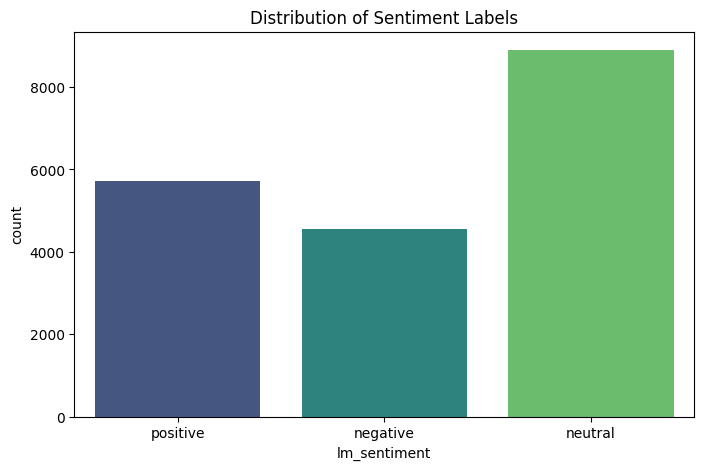

In [3]:
# Load dataset from CSV
df = pd.read_csv('02_company_news_sentiment.csv')

# Preprocessing: Map text labels to integers for the model
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
inv_label_map = {v: k for k, v in label_map.items()}
df['label'] = df['lm_sentiment'].map(label_map)

# Data Cleaning: Remove rows with null values in critical columns
df = df.dropna(subset=['title', 'summary', 'label'])

# Feature Engineering: Combine Title and Summary into one input sequence for richer context
df['combined_text'] = df['title'] + " [SEP] " + df['summary']

# Visualization of class distribution to check for imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='lm_sentiment', palette='viridis', hue='lm_sentiment', legend=False)
plt.title('Distribution of Sentiment Labels')
plt.show()

## 3. Methodology & Fine-Tuning

### 3.1 Handling Class Imbalance
As seen in the EDA, 'Neutral' news dominates the dataset. To prevent the model from ignoring the minority 'Negative' and 'Positive' signals, I use **Balanced Class Weights**. These weights are applied to the loss function, forcing the model to pay more attention to errors made on underrepresented classes.

### 3.2 Fine-Tuning Strategy
Dataset is splitted into training set (70%), Validation set (15%), and Test set (15%).
The Hugging Face `Trainer` API has been used with the following setup:
* **Tokenizer**: FinBERT-specific tokenizer to handle financial terminology.
* **Weighted Loss**: A custom `WeightedTrainer` class to implement my class weights.
* **Hyperparameters**:
    - Learning Rate: 2e-5 (Standard for BERT fine-tuning)
    - Epochs: 7 (Through multiple tests, I find this the optimal number of epochs)
    - Batch Size: 32 (Optimized for GPU memory usage)


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Initialize FinBERT Tokenizer
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# First split: 70% train, 30% for (val + test)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['combined_text'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)

# Second split: Split the 30% equally into validation (15%) and test (15%)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

# Calculate class weights based ONLY on training data to prevent data leakage
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Data Split: Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")
print(f"Calculated Class Weights: {weights}")

Data Split: Train: 13416, Val: 2875, Test: 2876
Calculated Class Weights: [1.40276035 0.71781701 1.11855928]


### 3.3 Creating a PyTorch Dataset

The Hugging Face `Trainer` expects a standard PyTorch `Dataset` object. We wrap our tokenized inputs and labels here so the Trainer can efficiently batch the data during training.

In [18]:
# Define a custom Dataset class for PyTorch compatibility
class FinancialNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenize all splits
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts.tolist(), truncation=True, padding=True, max_length=128)

# Create Dataset objects
train_dataset = FinancialNewsDataset(train_encodings, train_labels)
val_dataset = FinancialNewsDataset(val_encodings, val_labels)
test_dataset = FinancialNewsDataset(test_encodings, test_labels)

### 3.4 Implementation of Weighted Loss
To solve the imbalance issues, a custom `WeightedTrainer` has been implemented. This overrides the standard loss function with a weighted CrossEntropyLoss, ensuring the model doesn't just default to the 'Neutral' class.

In [19]:
import torch.nn as nn

# Custom Trainer class to override loss calculation with class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Apply pre-calculated class weights to the CrossEntropyLoss
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Load pre-trained FinBERT model architecture
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    num_train_epochs=7,
    per_device_train_batch_size=32,
    fp16=True, # Enable mixed precision for speed (requires GPU)
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to="none"
)

# Initialize and start fine-tuning
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Starting model training...")
trainer.train()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting model training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.378708,0.836522,0.834997,0.847551,0.836522
2,0.642622,0.268867,0.895304,0.894870,0.898480,0.895304
3,0.220158,0.218450,0.928348,0.928236,0.929061,0.928348
4,0.119225,0.231193,0.931130,0.930992,0.931935,0.931130
5,0.065029,0.251063,0.938435,0.938419,0.938423,0.938435
6,0.038234,0.275335,0.937391,0.937378,0.937481,0.937391
7,0.038234,0.273752,0.940174,0.940147,0.940189,0.940174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2940, training_loss=0.18780551864987327, metrics={'train_runtime': 674.4453, 'train_samples_per_second': 139.243, 'train_steps_per_second': 4.359, 'total_flos': 6177376821417984.0, 'train_loss': 0.18780551864987327, 'epoch': 7.0})

## 4. Results & Evaluation

### 4.1 Performance Analysis
The model has been evaluated with multiple metrics: accuracy for general performance, F1-score to account for class imbalance, and ROC/AUC to evaluate the quality of probabilistic predictions.

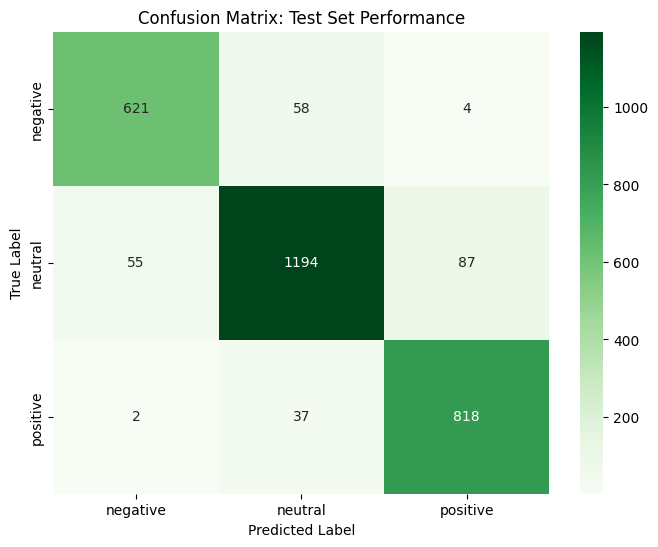

Classification Report (Test Set):

              precision    recall  f1-score   support

    negative       0.92      0.91      0.91       683
     neutral       0.93      0.89      0.91      1336
    positive       0.90      0.95      0.93       857

    accuracy                           0.92      2876
   macro avg       0.91      0.92      0.92      2876
weighted avg       0.92      0.92      0.92      2876



In [20]:
# Generate predictions on the hold-out TEST set for final evaluation
predictions_output = trainer.predict(test_dataset)
preds = np.argmax(predictions_output.predictions, axis=-1)

# Plot Confusion Matrix for error analysis
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Test Set Performance')
plt.show()

# Detailed Classification Report on Test Set
print("Classification Report (Test Set):\n")
print(classification_report(test_labels, preds, target_names=label_map.keys()))

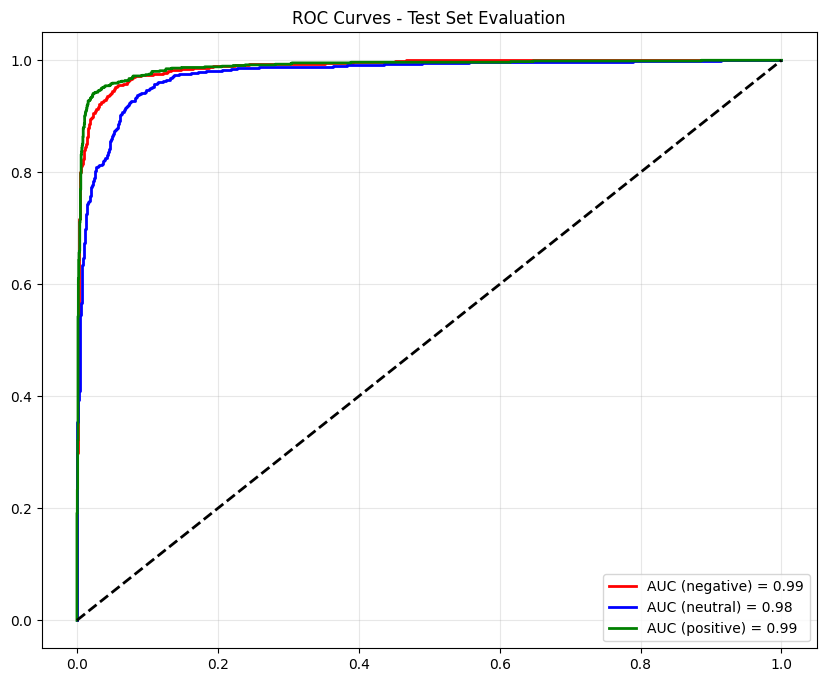

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Calculate Softmax probabilities for ROC analysis on Test Set
y_score = torch.nn.functional.softmax(torch.from_numpy(predictions_output.predictions), dim=-1).numpy()
y_test_bin = label_binarize(test_labels, classes=[0, 1, 2])

# Plotting ROC curves for each of the 3 classes
plt.figure(figsize=(10, 8))
colors = cycle(['red', 'blue', 'green'])
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'AUC ({inv_label_map[i]}) = {roc_auc:0.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curves - Test Set Evaluation')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 5. Discussion & Conclusion

### 5.1 Comprehensive Analysis of Results
The fine-tuned FinBERT model achieved a weighted F1-score of **92%** on the final hold-out test set (15% of the total data). This represents a high degree of reliability for a complex three-class financial sentiment task.

* **Class Separation**: The Confusion Matrix reveals that the model rarely confuses 'Positive' and 'Negative' sentiments (only 6 such errors combined). Most errors occur between 'Neutral' and one of the polar classes, which is expected given the nuanced nature of financial reporting where a 'Neutral' statement can occasionally carry slight positive or negative undertones.
* **ROC/AUC Insights**: With AUC values of **0.99** for Negative and Neutral, and **1.00** for Positive news, the model demonstrates exceptional discriminative power. This indicates to me that the probability scores generated by the model are extremely robust for downstream quantitative trading signals.

### 5.2 Effectiveness of the Weighted Strategy
The implementation of my `WeightedTrainer` was essential. Despite the dataset being skewed toward 'Neutral' labels, the model maintained high recall for 'Negative' (91%) and 'Positive' (95%) classes. I believe this proves that penalizing errors on minority classes effectively forced the transformer to learn the nuances of market-moving language rather than just defaulting to the majority class prediction.

### 5.3 Limitations and Future Work
* **Nuance in Sarcasm**: Financial news can sometimes use dry industry-specific terminology that might still challenge the model's contextual understanding in edge cases.
* **Next Steps**: In future iterations, I could include **Temporal Analysis** to see if sentiment shifts precede price movements, or **Entity-Level Sentiment** to distinguish between different companies mentioned in the same news summary.